### Notebook creado para testear las mejoras o correciones sobre CROP. solo a nivel funcional.

### Preuba de crop 1

2025-11-24 11:56:26.690067: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 11:56:26.693493: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 11:56:26.704343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763996186.720459  371194 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763996186.725272  371194 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763996186.738075  371194 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando fashion como dataset


2025-11-24 11:56:29.438252: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-11-24 11:56:29.438271: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-11-24 11:56:29.438276: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: pc-santi
2025-11-24 11:56:29.438280: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: pc-santi
2025-11-24 11:56:29.438338: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 575.64.3
2025-11-24 11:56:29.438356: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] kernel reported version is: 575.64.3
2025-

gt1: tf.Tensor(
[[1.1297003e-06 9.9999005e-01 1.3000955e-07 8.3669456e-06 2.7184112e-07
  5.6211085e-09 5.8915455e-09 9.7653585e-10 6.1813299e-10 4.5359547e-10]
 [8.1156009e-05 2.2235175e-05 9.9331403e-01 1.7280659e-07 2.9221611e-04
  2.9719070e-07 6.2898602e-03 1.4332386e-09 1.7964441e-08 4.0570050e-09]
 [1.3460402e-06 9.9999756e-01 1.3879458e-08 7.6416813e-07 2.5126735e-07
  5.3749432e-09 3.9477235e-09 6.8072971e-11 4.7862009e-10 5.9296630e-12]
 [4.0557966e-06 9.9996263e-01 5.9892244e-07 1.8488381e-05 1.4207366e-05
  4.1814534e-08 2.9783861e-08 2.5116766e-08 1.2775523e-08 6.2715606e-09]
 [7.6248154e-02 4.7239643e-02 1.7344443e-02 5.6784980e-02 1.6684709e-02
  1.5648494e-06 7.8565383e-01 4.6293162e-06 2.8781833e-05 9.2251794e-06]
 [1.6653573e-03 9.9812394e-01 4.2725005e-05 1.0751283e-04 4.6558449e-05
  2.9220988e-07 7.9848569e-06 1.9441757e-07 5.1584507e-06 3.6328220e-07]
 [3.8086981e-04 7.7778139e-05 4.2491007e-01 7.4968470e-05 4.7973141e-01
  2.3556243e-04 7.2159886e-02 3.4855898e-0

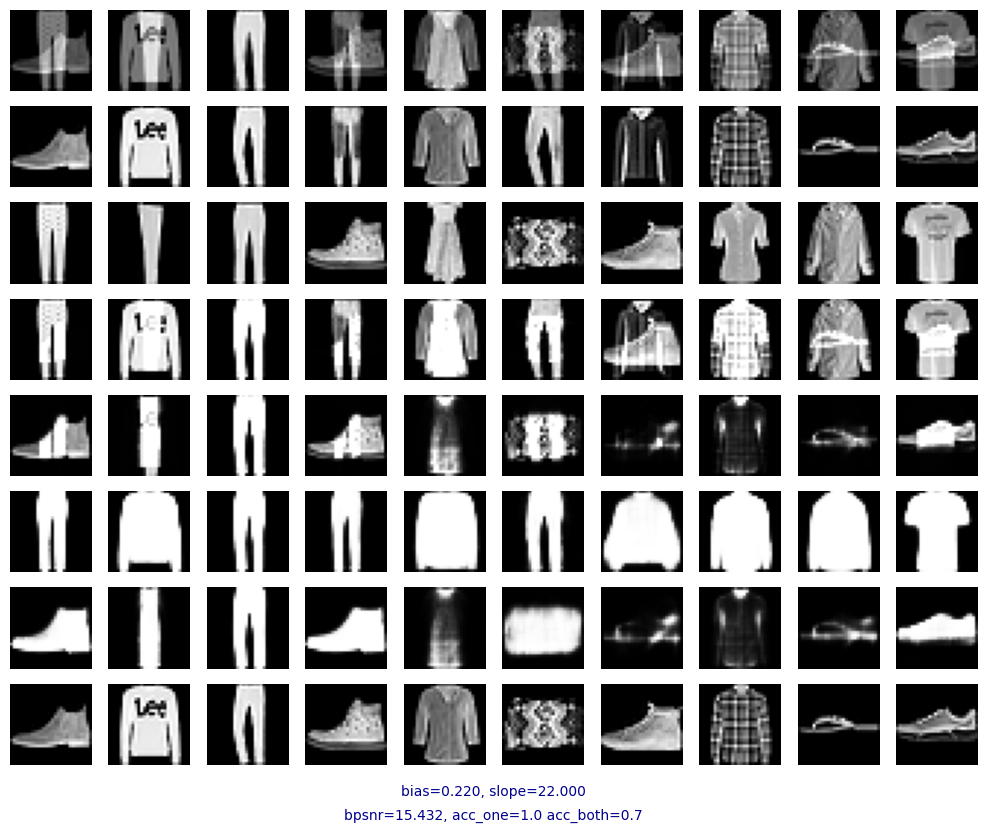

tf.Tensor(15.432379, shape=(), dtype=float32)
1.0
0.7


In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop1 import Crop1
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop1 = Crop1(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = crop1.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### prueba de crop 2


Usando fashion como dataset
gt1: tf.Tensor(
[[1.26367780e-07 9.99999225e-01 4.11918588e-09 4.27572104e-07
  1.22900374e-07 4.12552076e-10 9.94148652e-10 8.39172620e-11
  2.33144528e-11 2.95854313e-11]
 [1.83133670e-04 4.28725343e-06 9.90168512e-01 5.36560947e-07
  2.13079224e-03 1.00880683e-07 7.51271611e-03 3.40501516e-09
  2.81602315e-08 3.56986840e-09]
 [1.37766719e-07 9.99999702e-01 6.78349155e-10 5.50275665e-08
  1.31403269e-07 2.01316352e-10 8.71788752e-10 6.88473931e-12
  1.76259660e-10 1.08467976e-12]
 [4.71230663e-07 9.99995887e-01 1.88578380e-08 8.62802722e-07
  2.70338182e-06 1.16524146e-09 4.15886525e-09 1.48258372e-09
  3.65915409e-10 3.39676176e-10]
 [1.81815237e-01 9.36877262e-03 1.25688501e-02 1.08510539e-01
  4.70522605e-02 3.85955417e-07 6.40593350e-01 1.94101017e-06
  8.30775534e-05 5.58198235e-06]
 [2.72451929e-04 9.99697208e-01 3.88217632e-06 5.49392098e-06
  1.73825229e-05 1.19821397e-08 3.15694001e-06 1.05473097e-08
  4.83862379e-07 1.81091142e-08]
 [2.04365497e-

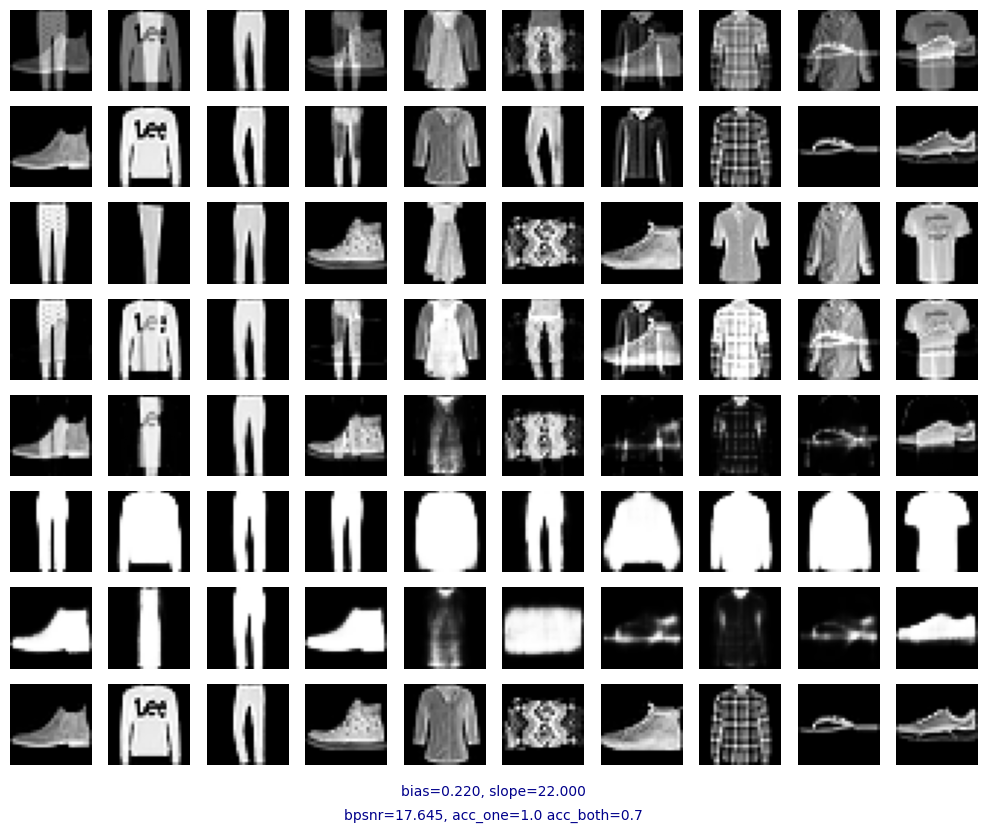

tf.Tensor(17.64498, shape=(), dtype=float32)
1.0
0.7


In [2]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop2 import Crop2
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop2 = Crop2(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = crop2.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params = {"gamma":0.9}
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### Crop norm


Usando fashion como dataset


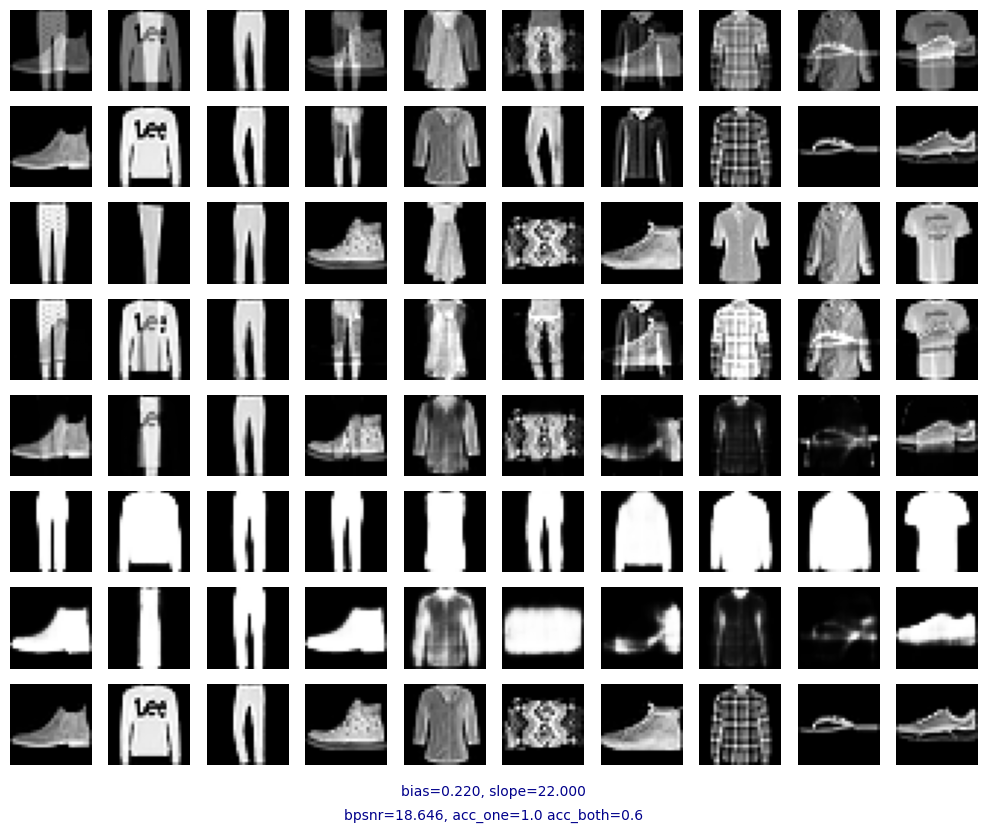

(<tf.Tensor: shape=(), dtype=float32, numpy=18.645732879638672>, <tf.Tensor: shape=(), dtype=float32, numpy=3.713440179824829>)
1.0
0.6


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop2_norm import Crop2Norm
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop2Norm = Crop2Norm(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = crop2Norm.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params = {"gamma":0.9}
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### Crop2 gamma norm

Usando fashion como dataset


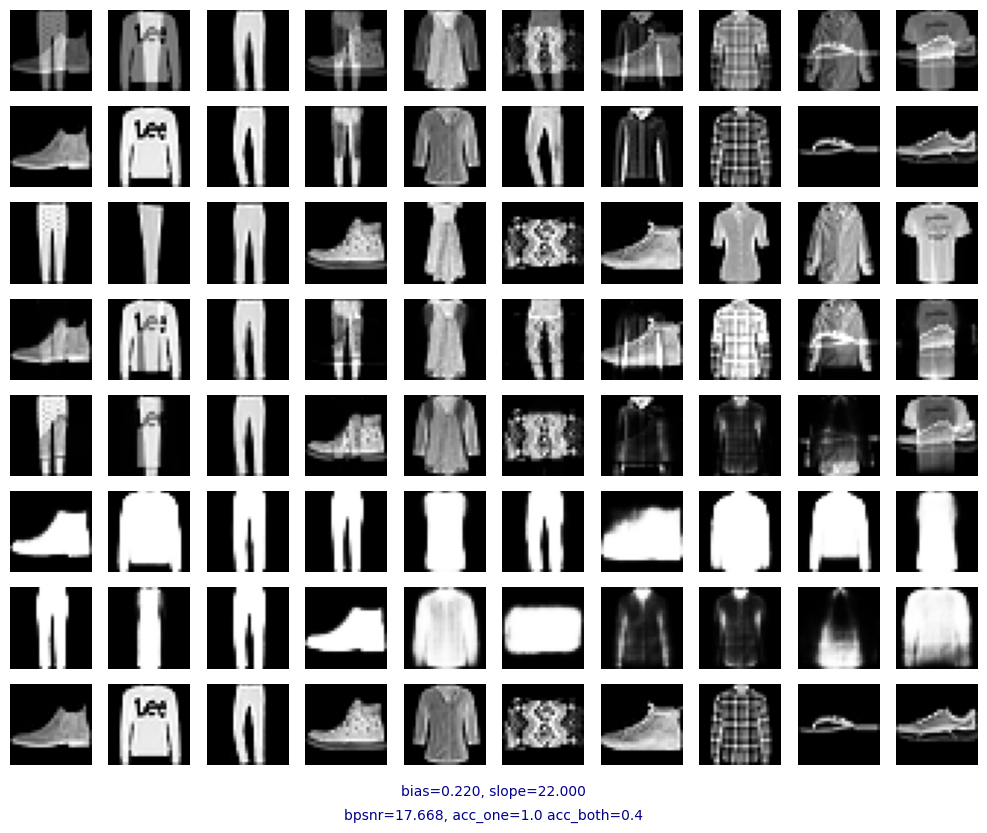

(<tf.Tensor: shape=(), dtype=float32, numpy=17.667552947998047>, <tf.Tensor: shape=(), dtype=float32, numpy=4.12006139755249>)
1.0
0.4


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop2_gamma_norm import Crop2GammaNorm
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


Crop2GammaNorm = Crop2GammaNorm(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = Crop2GammaNorm.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params = {"gamma":0.9}
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### modelo de prueba

Usando fashion como dataset
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)
forma de las predicciones
(10, 10)


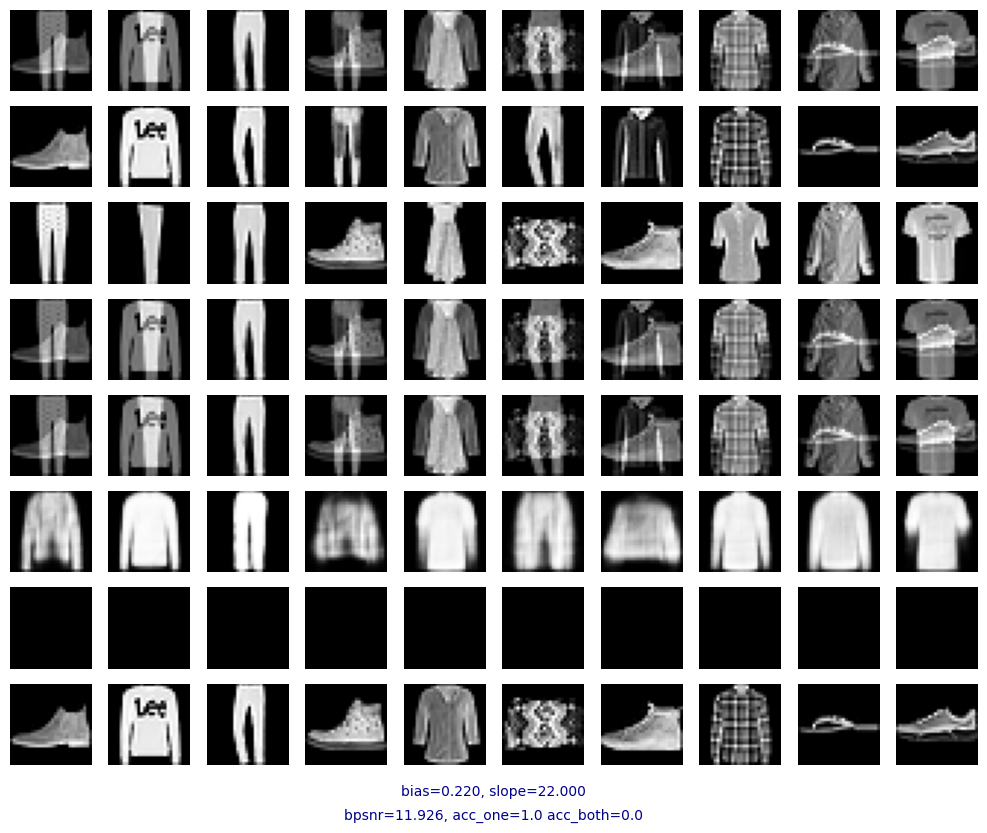

(<tf.Tensor: shape=(), dtype=float32, numpy=11.925819396972656>, <tf.Tensor: shape=(), dtype=float32, numpy=1.347177267074585>)
1.0
0.0


In [ ]:

import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop_test import CropTest

dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


CropTest1 = CropTest(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = CropTest1.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params={"mm1":1,"mm2":0,"rsm1":0.5,"rsm2":0.25}

)

print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])


### Curvas de acc



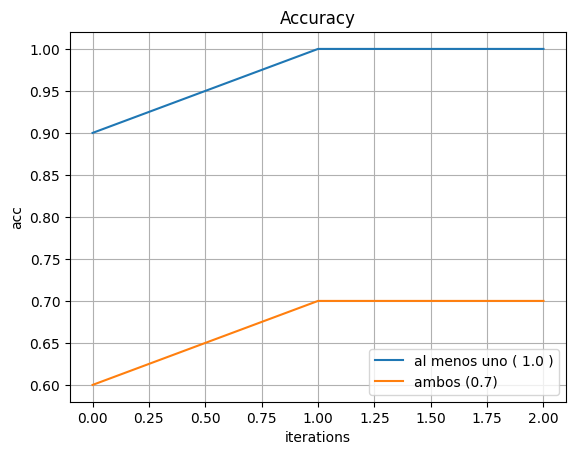

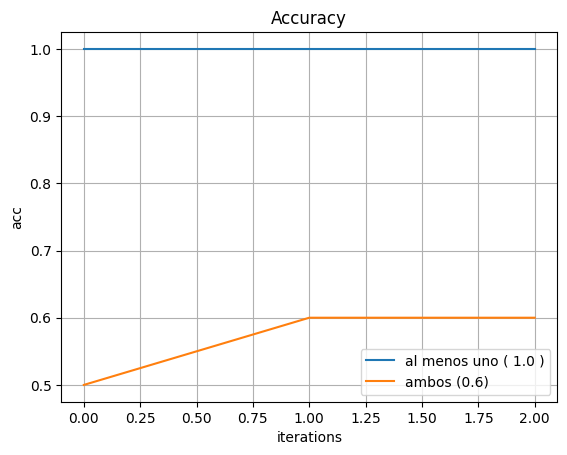

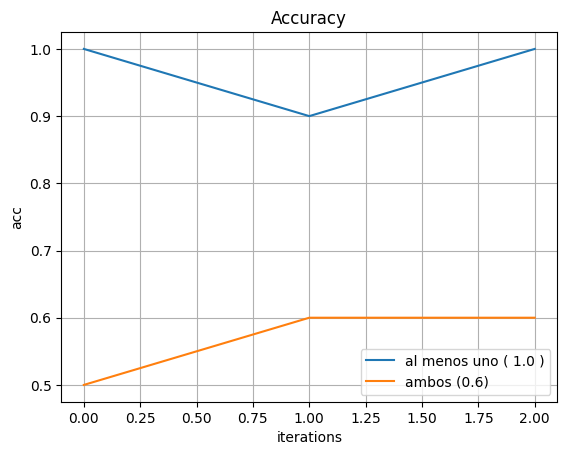

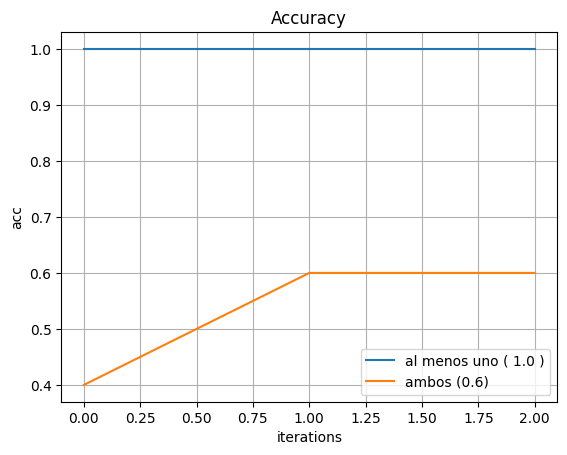

{'acc_at_least_one_plot': [1.0, 1.0, 1.0], 'acc_both_plot': [0.4, 0.6, 0.6]}

In [ ]:
crop1.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)
crop2.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)
crop2Norm.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)
Crop2GammaNorm.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)

